In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## take a look at the data

In [106]:
sensor_data = pd.read_csv("PressureSensorData.csv")

In [107]:
sensor_data.head()

,test_id,pt_psia,pa_psia,pd_volts
0,1.0,5,4,0.2834
1,1.0,10,10,0.3655
2,1.0,15,14,0.4469
3,1.0,35,34,0.7752
4,1.0,55,56,1.1028


In [108]:
sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   test_id   107 non-null    float64
 1   pt_psia   108 non-null    int64  
 2   pa_psia   108 non-null    int64  
 3   pd_volts  108 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 3.5 KB


In [109]:
sensor_data.describe()

,test_id,pt_psia,pa_psia,pd_volts
count,107.000000,108.000000,108.000000,108.000000
mean,4.990654,83.750000,82.842593,1.575580
std,2.604406,58.442099,58.235930,0.958096
min,1.000000,5.000000,4.000000,0.283000
25%,3.000000,30.000000,29.250000,0.695842
50%,5.000000,85.000000,85.000000,1.595300
75%,7.000000,130.000000,129.000000,2.336950
max,9.000000,175.000000,174.000000,3.074700


## look for null values

In [110]:
sensor_data.isnull().any() # find if any columns have null values

test_id      True
pt_psia     False
pa_psia     False
pd_volts    False
dtype: bool

In [111]:
sensor_data["test_id"].isnull().value_counts()
# we find that we have one null value in entire database

test_id
False    107
True       1
Name: count, dtype: int64

In [121]:
sensor_data.isnull().value_counts() # anothe way to look at it

test_id  pt_psia  pa_psia  pd_volts
False    False    False    False       107
True     False    False    False         1
Name: count, dtype: int64

## Look at correlations between variables

In [113]:
# find some correlations 
sensor_data.corr()

,test_id,pt_psia,pa_psia,pd_volts
test_id,1.000000,0.005257,0.000847,0.005896
pt_psia,0.005257,1.000000,0.999799,0.999972
pa_psia,0.000847,0.999799,1.000000,0.999786
pd_volts,0.005896,0.999972,0.999786,1.000000


## Data Visualization
#### Analog values

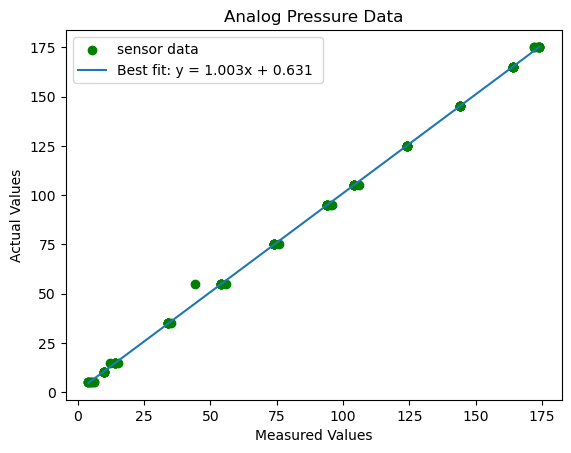

In [114]:
# plot analog pressures
plt.scatter(x = sensor_data["pa_psia"], y = sensor_data["pt_psia"], color = "green", label = "sensor data")
plt.title("Analog Pressure Data")
plt.xlabel("Measured Values")
plt.ylabel("Actual Values")

# add best fitting line
m,b = np.polyfit(sensor_data["pa_psia"], sensor_data["pt_psia"], 1)
line = lambda x: x*m +b

x_axis = np.linspace(min(sensor_data["pa_psia"]), max(sensor_data["pa_psia"]), 200)
best_line = line(x_axis)

plt.plot(x_axis,best_line, label = f"Best fit: y = {round(m,3)}x + {round(b, 3)} ")
plt.legend()

plt.show()

In [115]:
analog_coef = round(np.corrcoef(sensor_data["pa_psia"], sensor_data["pt_psia"])[0][1], 6)
print(f"the coefficient of correlatio is {analog_coef}")

the coefficient of correlatio is 0.999799


#### Pressure Transducer

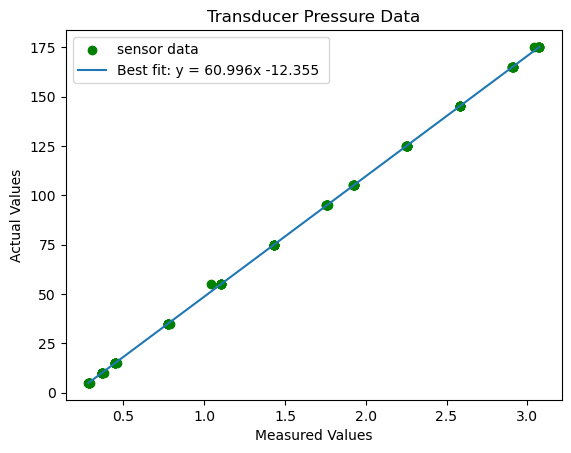

In [116]:
# plot transducer measurements
plt.scatter(x = sensor_data["pd_volts"], y = sensor_data["pt_psia"], color = "green", label = "sensor data")
plt.title("Transducer Pressure Data")
plt.xlabel("Measured Values")
plt.ylabel("Actual Values")

# add best fitting line
m,b = np.polyfit(sensor_data["pd_volts"], sensor_data["pt_psia"], 1)
line = lambda x: x*m +b

x_axis = np.linspace(min(sensor_data["pd_volts"]), max(sensor_data["pd_volts"]), 200)
best_line = line(x_axis)

plt.plot(x_axis,best_line, label = f"Best fit: y = {round(m,3)}x {round(b, 3)} ")
plt.legend()

plt.show()

In [122]:
transducer_coef = round(np.corrcoef(sensor_data["pd_volts"], sensor_data["pt_psia"])[0][1], 6)
print(f"the coefficient of correlation is {transducer_coef}")

the coefficient of correlation is 0.999972


### see how well our linear fit predicted values

In [124]:
# how accurate is our best fit line for the analog readings? what is the coefficient of correlation?
m,b = np.polyfit(sensor_data["pa_psia"], sensor_data["pt_psia"], 1)
line_func = lambda x: x*m +b

x_axis = sensor_data["pa_psia"]
predicted_values = line_func(x_axis)

line_fit = np.corrcoef(predicted_values, sensor_data["pt_psia"])[0][1]

print(f"The coefficient of correlation for our analog reading is {round(line_fit, 6)}")

The coefficient of correlation for our analog reading is 0.999799


In [125]:
# how accurate is our best fit line for the pressure transducer readings? what is the coefficient of correlation?
m,b = np.polyfit(sensor_data["pd_volts"], sensor_data["pt_psia"], 1)
line_func = lambda x: x*m +b

x_axis = sensor_data["pd_volts"]
predicted_values = line_func(x_axis)

line_fit = np.corrcoef(predicted_values, sensor_data["pt_psia"])[0][1]

print(f"The coefficient of correlation for our presure transducer is {round(line_fit, 6)}")

The coefficient of correlation for our presure transducer is 0.999972
